# Task 7 - Distributed Optimization

Notebook version of the Task 7 distributed optimization algorithm. The notation follows the assignment: stores are indexed by `n`, timeslots by `t`, heating power is `p_n_t`, multipliers are `lambda_t`, and weights are `w_n`.

In [10]:
from __future__ import annotations
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as spo
from pyomo.environ import *
from DataTask7 import fetch_data

## 1. Load Data

The fixed Task 7 parameters are read from `DataTask7.py`. The two room occupancy time series are read from `Task7Occupancies.csv`.

In [11]:
def load_task7_data(folder="."):
    params = fetch_data()
    T = int(params["num_timeslots"])
    N = 15

    occupancy_path = Path(folder) / "Task7Occupancies.csv"
    if not occupancy_path.exists():
        raise FileNotFoundError("Task7Occupancies.csv was not found in the notebook folder.")

    occupancy_raw = pd.read_csv(occupancy_path)
    occupancy_numeric = occupancy_raw.iloc[:, :T].apply(pd.to_numeric, errors="coerce")
    occupancy_room1 = occupancy_numeric.iloc[0].to_numpy(dtype=float)
    occupancy_room2 = occupancy_numeric.iloc[1].to_numpy(dtype=float)
    occupancy_mean = 0.5 * (occupancy_room1 + occupancy_room2)

    task7_df = pd.DataFrame({
        "t": np.arange(T),
        "T_out": np.asarray(params["outdoor_temperature"], dtype=float),
        "occupancy_room1": occupancy_room1,
        "occupancy_room2": occupancy_room2,
        "occupancy_mean": occupancy_mean,
    })

    data = {
        "N": N,
        "T": T,
        "P_mall": float(params["P_mall"]),
        "T_ref": float(params["Temperature_reference"]),
        "T_initial": float(params["initial_temperature"]),
        "P_room_max": float(params["heating_max_power"]),
        "P_store_max": 2.0 * float(params["heating_max_power"]),
        "zeta_exch": float(params["heat_exchange_coeff"]),
        "zeta_loss": float(params["thermal_loss_coeff"]),
        "zeta_conv": float(params["heating_efficiency_coeff"]),
        "zeta_cool": float(params["heat_vent_coeff"]),
        "zeta_occ": float(params["heat_occupancy_coeff"]),
        "rho_balance": 0.05,
        "T_out": task7_df["T_out"].to_numpy(),
        "occupancy_room1": task7_df["occupancy_room1"].to_numpy(),
        "occupancy_room2": task7_df["occupancy_room2"].to_numpy(),
        "w_n": np.arange(1, N + 1, dtype=float) + 1.0,
    }
    return data, task7_df

In [12]:
folder = Path.cwd()

data, task7_df = load_task7_data(folder)
print(task7_df)
print(data)

   t     T_out  occupancy_room1  occupancy_room2  occupancy_mean
0  0 -3.000000        32.969098        15.471041       24.220069
1  1 -2.427051        34.098942        19.416995       26.757968
2  2 -0.927051        33.617007        20.760380       27.188693
3  3  0.927051        35.445151        24.827505       30.136328
4  4  2.427051        32.503181        30.000000       31.251591
5  5  3.000000        30.244813        29.734117       29.989465
6  6  2.427051        24.592165        29.678559       27.135362
7  7  0.927051        25.693216        25.438845       25.566030
8  8 -0.927051        29.555435        22.523491       26.039463
9  9 -2.427051        26.972916        18.750108       22.861512
{'N': 15, 'T': 10, 'P_mall': 45.0, 'T_ref': 21.0, 'T_initial': 21.0, 'P_room_max': 3.0, 'P_store_max': 6.0, 'zeta_exch': 0.6, 'zeta_loss': 0.1, 'zeta_conv': 1.0, 'zeta_cool': 0.7, 'zeta_occ': 0.02, 'rho_balance': 0.05, 'T_out': array([-3.        , -2.42705098, -0.92705098,  0.92705098

## 2. Coupled Two-Room Store Model

Each store keeps two separate temperature trajectories and two separate occupancy series. The objective follows Eq. (2) with an explicit sum over rooms, so for each store the weighted squared deviation from `T_ref` is accumulated for room 1 and room 2 separately. In the implemented model, the two rooms are heated by separate room-wise heating powers while sharing the same store weight and the same mall-level electricity capacity constraint.

In [13]:
def room_temperature_linear_model(data, room_key):
    """Return A, b such that T_room_t = A @ p_room + b for one room."""
    T = data["T"]
    A = np.zeros((T, T))
    b = np.zeros(T)
    a = 1.0 - data["zeta_loss"]
    beta = data["zeta_conv"]

    for t in range(T):
        for j in range(t + 1):
            A[t, j] = beta * (a ** (t - j))

    T_without_heating = data["T_initial"]
    occupancy = data[room_key]
    for t in range(T):
        occupancy_heat_gain = data["zeta_occ"] * occupancy[t]
        T_without_heating = (
            a * T_without_heating
            + data["zeta_loss"] * data["T_out"][t]
            - data["zeta_cool"]
            + occupancy_heat_gain
        )
        b[t] = T_without_heating
    return A, b


def temperature_linear_model(data):
    """Return linear models for room 1 and room 2."""
    A1, b1 = room_temperature_linear_model(data, "occupancy_room1")
    A2, b2 = room_temperature_linear_model(data, "occupancy_room2")
    return A1, b1, A2, b2


def split_power_vector(data, p_n):
    """Split a stacked 2T-vector into room 1 and room 2 heating powers."""
    T = data["T"]
    return p_n[:T], p_n[T:]


def stack_power_vectors(p_room1, p_room2):
    return np.concatenate([p_room1, p_room2])


def simulate_temperature(data, p_room1, p_room2):
    A1, b1, A2, b2 = temperature_linear_model(data)
    T_room1 = np.concatenate([[data["T_initial"]], A1 @ p_room1 + b1])
    T_room2 = np.concatenate([[data["T_initial"]], A2 @ p_room2 + b2])
    return T_room1, T_room2


def store_cost_and_grad(data, n, p_n, lambda_t=None):
    A1, b1, A2, b2 = temperature_linear_model(data)
    p_room1, p_room2 = split_power_vector(data, p_n)
    w_n = data["w_n"][n]
    T_room1 = A1 @ p_room1 + b1
    T_room2 = A2 @ p_room2 + b2
    error1 = T_room1 - data["T_ref"]
    error2 = T_room2 - data["T_ref"]
    value = w_n * float(error1 @ error1 + error2 @ error2)
    grad1 = 2.0 * w_n * (A1.T @ error1)
    grad2 = 2.0 * w_n * (A2.T @ error2)
    if lambda_t is not None:
        value += float(lambda_t @ (p_room1 + p_room2))
        grad1 += lambda_t
        grad2 += lambda_t
    return value, stack_power_vectors(grad1, grad2)


def system_objective(data, p_n_t):
    objective = 0.0
    for n in range(data["N"]):
        objective += store_cost_and_grad(
            data,
            n,
            stack_power_vectors(p_n_t[n, 0, :], p_n_t[n, 1, :]),
            None,
        )[0]
    return float(objective)

In [14]:
A1, b1, A2, b2 = temperature_linear_model(data)
print("A1 shape:", A1.shape)
print("b1:", np.round(b1, 3))
print("A2 shape:", A2.shape)
print("b2:", np.round(b2, 3))
task7_df

A1 shape: (10, 10)
b1: [18.559 16.443 14.678 13.312 12.173 11.161 10.079  8.978  7.879  6.688]
A2 shape: (10, 10)
b2: [18.209 15.834 13.873 12.375 11.28  10.347  9.449  8.405  7.222  5.932]


,t,T_out,occupancy_room1,occupancy_room2,occupancy_mean
0,0,-3.000000,32.969098,15.471041,24.220069
1,1,-2.427051,34.098942,19.416995,26.757968
2,2,-0.927051,33.617007,20.760380,27.188693
3,3,0.927051,35.445151,24.827505,30.136328
4,4,2.427051,32.503181,30.000000,31.251591
5,5,3.000000,30.244813,29.734117,29.989465
6,6,2.427051,24.592165,29.678559,27.135362
7,7,0.927051,25.693216,25.438845,25.566030
8,8,-0.927051,29.555435,22.523491,26.039463
9,9,-2.427051,26.972916,18.750108,22.861512


## 3. Local and joint centralized Optimization

Each store solves its own local problem for a given `lambda_t`. In the implemented two-room version, each store optimizes separate heating powers for room 1 and room 2. For comparation the problem is solved as joint optimization problem.

In [15]:
def local_store_solution(data, n, lambda_t):
    """Solve store n's local convex two-room problem by bounded quasi-Newton optimization."""
    initial_room_power = min(data["P_room_max"], data["P_mall"] / (2.0 * data["N"]))
    p0 = np.full(2 * data["T"], initial_room_power)
    bounds = [(0.0, data["P_room_max"])] * (2 * data["T"])

    def objective(p_n):
        return store_cost_and_grad(data, n, p_n, lambda_t)[0]

    def gradient(p_n):
        return store_cost_and_grad(data, n, p_n, lambda_t)[1]

    result = spo.minimize(
        objective,
        p0,
        jac=gradient,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 300, "ftol": 1e-10},
    )
    return result.x


def project_capped_simplex(v, cap, total_cap):
    """Project v onto {0 <= x_i <= cap, sum_i <= total_cap}."""
    y = np.clip(v, 0.0, cap)
    if y.sum() <= total_cap:
        return y

    lo = np.min(v - cap)
    hi = np.max(v)
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        x = np.clip(v - mid, 0.0, cap)
        if x.sum() > total_cap:
            lo = mid
        else:
            hi = mid
    return np.clip(v - hi, 0.0, cap)


def project_mall_feasible(data, p_n_t):
    out = np.zeros_like(p_n_t)
    for t in range(data["T"]):
        projected = project_capped_simplex(
            p_n_t[:, :, t].reshape(-1),
            data["P_room_max"],
            data["P_mall"],
        )
        out[:, :, t] = projected.reshape(data["N"], 2)
    return out


def solve_centralized(data, iterations=6000):
    """Projected gradient centralized benchmark for two room-wise powers per store."""
    start = pd.Timestamp.now()
    initial_room_power = min(data["P_room_max"], data["P_mall"] / (2.0 * data["N"]))
    p_n_t = np.full((data["N"], 2, data["T"]), initial_room_power)
    p_n_t = project_mall_feasible(data, p_n_t)
    A1, _, A2, _ = temperature_linear_model(data)
    max_w = np.max(data["w_n"])
    lip = max(
        2.0 * max_w * max(np.linalg.norm(A1.T @ A1, 2), np.linalg.norm(A2.T @ A2, 2)),
        1e-8,
    )
    step = 0.8 / lip

    for _ in range(iterations):
        grad = np.zeros_like(p_n_t)
        for n in range(data["N"]):
            _, grad_n = store_cost_and_grad(
                data,
                n,
                stack_power_vectors(p_n_t[n, 0, :], p_n_t[n, 1, :]),
                None,
            )
            grad[n, 0, :], grad[n, 1, :] = split_power_vector(data, grad_n)
        p_n_t_new = project_mall_feasible(data, p_n_t - step * grad)
        if np.linalg.norm(p_n_t_new - p_n_t) < 1e-7:
            p_n_t = p_n_t_new
            break
        p_n_t = p_n_t_new

    elapsed = (pd.Timestamp.now() - start).total_seconds()
    return p_n_t, system_objective(data, p_n_t), elapsed

In [16]:
p_n_t_central, central_obj, central_runtime = solve_centralized(data)
print(f"Centralized objective value: {central_obj:.4f}")
print(f"Centralized runtime: {central_runtime:.4f} s")

Centralized objective value: 20778.5893
Centralized runtime: 23.7180 s


## 4. Distributed Dual Decomposition

The coordinator broadcasts `lambda_t`. Every store solves a local two-room problem. The coordinator then updates `lambda_t` from the mall capacity violation `sum_{n,r} p_{n,r,t} - P_mall`.

In [17]:
def run_distributed(data, alpha=0.1, iterations=100, adaptive=False, alpha0=5.0):
    start = pd.Timestamp.now()
    lambda_t = np.zeros(data["T"])
    obj_hist = np.zeros(iterations)
    lambda_hist = np.zeros((iterations, data["T"]))
    violation_hist = np.zeros((iterations, data["T"]))
    p_n_t_hist = np.zeros((iterations, data["N"], 2, data["T"]))

    for k in range(iterations):
        p_n_t = np.zeros((data["N"], 2, data["T"]))
        for n in range(data["N"]):
            p_opt = local_store_solution(data, n, lambda_t)
            p_room1, p_room2 = split_power_vector(data, p_opt)
            p_n_t[n, 0, :] = p_room1
            p_n_t[n, 1, :] = p_room2

        violation = p_n_t.sum(axis=(0, 1)) - data["P_mall"]
        obj_hist[k] = system_objective(data, p_n_t)
        lambda_hist[k, :] = lambda_t
        violation_hist[k, :] = violation
        p_n_t_hist[k, :, :, :] = p_n_t

        alpha_k = alpha0 / (1.0 + k) if adaptive else alpha
        lambda_t = np.maximum(0.0, lambda_t + alpha_k * violation)

    elapsed = (pd.Timestamp.now() - start).total_seconds()
    return {
        "objective": obj_hist,
        "lambda": lambda_hist,
        "violation": violation_hist,
        "p_n_t": p_n_t_hist,
        "runtime_seconds": elapsed,
    }

In [18]:
results = {}

for alpha in [0.001, 0.01, 0.1, 1.0, 10.0]:
    print(f"Running distributed algorithm for alpha={alpha}")
    results[f"alpha={alpha}"] = run_distributed(data, alpha=alpha, iterations=100)
    print(f"Runtime for alpha={alpha}: {results[f'alpha={alpha}']['runtime_seconds']:.4f} s")

print("Running distributed algorithm for adaptive alpha_k=5/(1+k)")
results["adaptive alpha0=5"] = run_distributed(data, iterations=100, adaptive=True, alpha0=5.0)
print(f"Runtime for adaptive alpha0=5: {results['adaptive alpha0=5']['runtime_seconds']:.4f} s")

print("Done.")

Running distributed algorithm for alpha=0.001
Runtime for alpha=0.001: 7.8201 s
Running distributed algorithm for alpha=0.01
Runtime for alpha=0.01: 6.7973 s
Running distributed algorithm for alpha=0.1
Runtime for alpha=0.1: 6.0535 s
Running distributed algorithm for alpha=1.0
Runtime for alpha=1.0: 6.4713 s
Running distributed algorithm for alpha=10.0
Runtime for alpha=10.0: 1.8112 s
Running distributed algorithm for adaptive alpha_k=5/(1+k)
Runtime for adaptive alpha0=5: 5.9023 s
Done.


## 5. Plots

There is the objective value over iterations plotted. The multiplier and capacity violation evolution is plotted for further analysis.

In [ ]:
def plot_objectives(results, centralized_obj):
    plt.figure(figsize=(10, 6))
    for label, res in results.items():
        plt.plot(res["objective"], linewidth=1.7, label=label)
    plt.axhline(
        centralized_obj,
        color="black",
        linestyle="--",
        linewidth=2.0,
        label="centralized optimum"
    )

    plt.xlabel("iteration k", fontsize=13)
    plt.ylabel(r"$\sum_{n=1}^{N}\sum_{r=1}^{2}\sum_{t\in\mathcal{T}} w_n\,(T_{n,r,t}-T^{ref})^2$", fontsize=13)
    plt.title("Objective value across iterations", fontsize=14)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()


def plot_lambdas_and_violations(results):
    for label, res in results.items():
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

        for t in range(res["lambda"].shape[1]):
            axes[0].plot(res["lambda"][:, t], linewidth=1.4, label=f"t={t}")

        axes[0].set_xlabel("iteration k", fontsize=13)
        axes[0].set_ylabel(r"$\lambda_t$", fontsize=13)
        axes[0].set_title(f"Multiplier evolution, {label}", fontsize=14)
        axes[0].tick_params(axis="both", labelsize=12)
        axes[0].grid(True, alpha=0.3)

        for t in range(res["violation"].shape[1]):
            axes[1].plot(res["violation"][:, t], linewidth=1.3, label=f"t={t}")

        axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.3)
        axes[1].set_xlabel("iteration k", fontsize=13)
        axes[1].set_ylabel(r"$\sum_{n,r} p_{n,r,t} - P^{mall}$", fontsize=13)
        axes[1].set_title(f"Capacity violation evolution, {label}", fontsize=14)
        axes[1].tick_params(axis="both", labelsize=12)
        axes[1].grid(True, alpha=0.3)

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=10)

        fig.tight_layout(rect=[0, 0.08, 1, 1])
        plt.show()

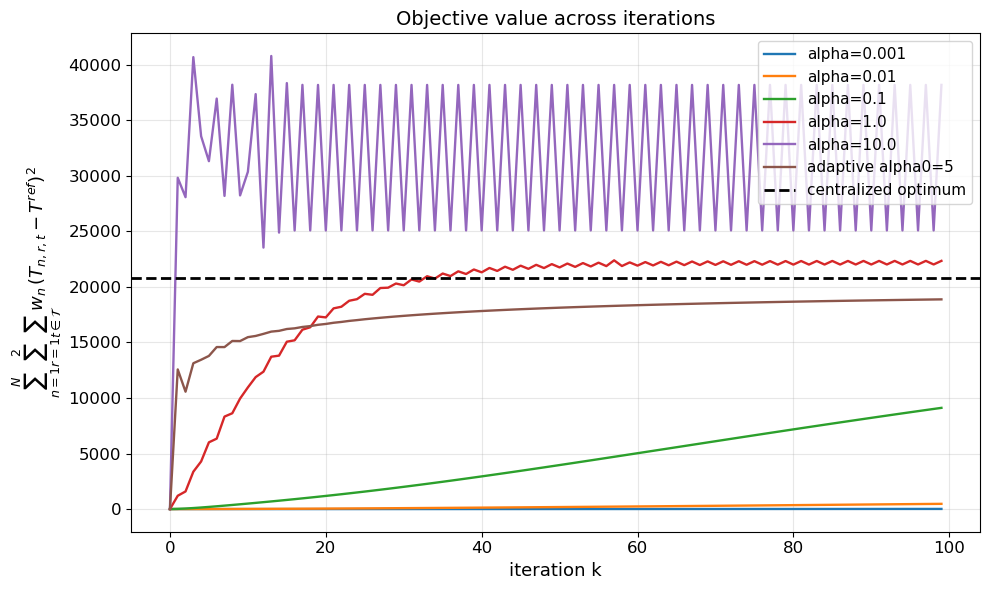

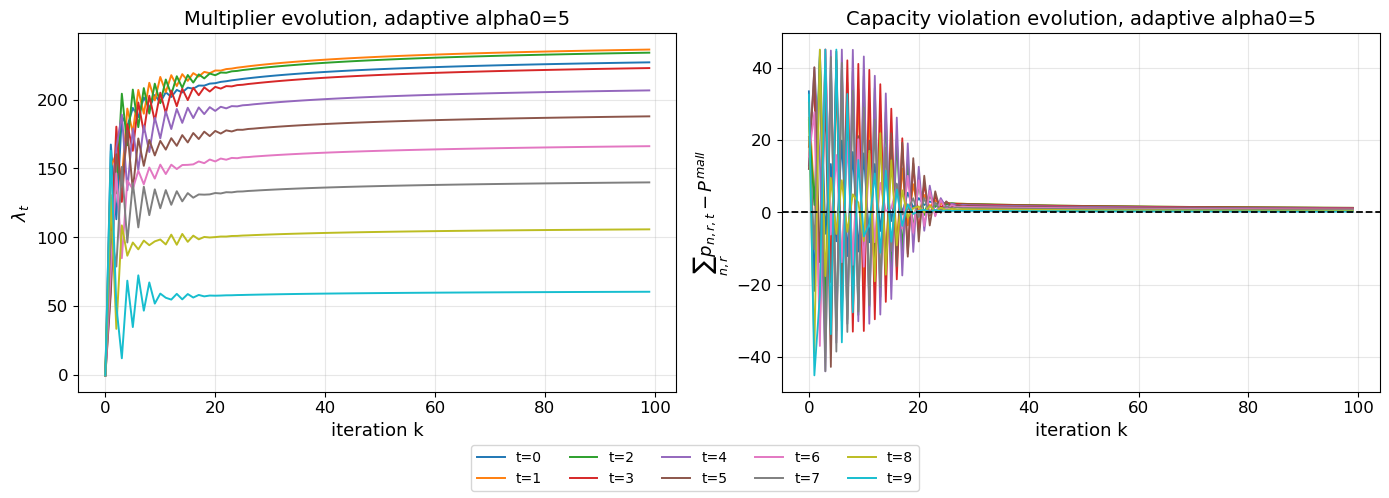

In [20]:
plot_objectives(results, central_obj)

results_best_alpha = {"adaptive alpha0=5": results["adaptive alpha0=5"]}

plot_lambdas_and_violations(results_best_alpha)

## 6. Runtime Comparison

The table below compares only the computational runtime of the joint optimization and the distributed optimization runs.

In [21]:
runtime_rows = [
    {
        "method": "Joint optimization",
        "runtime_seconds": central_runtime,
    }
]

for label, res in results.items():
    runtime_rows.append({
        "method": f"Distributed ({label})",
        "runtime_seconds": res["runtime_seconds"],
    })

runtime_comparison = pd.DataFrame(runtime_rows)
runtime_comparison = runtime_comparison.sort_values("runtime_seconds").reset_index(drop=True)
runtime_comparison

,method,runtime_seconds
0,Distributed (alpha=10.0),1.811186
1,Distributed (adaptive alpha0=5),5.902281
2,Distributed (alpha=0.1),6.053521
3,Distributed (alpha=1.0),6.471310
4,Distributed (alpha=0.01),6.797333
5,Distributed (alpha=0.001),7.820149
6,Joint optimization,23.718007


## 7. Store Energy Summary

The adaptive alpha version is considered further. Total energy consumption of all stores is compared.

In [22]:
def store_energy_summary(data, p_n_t):
    energy = p_n_t.sum(axis=(1, 2))
    return pd.DataFrame({
        "store_n": np.arange(1, data["N"] + 1),
        "w_n": data["w_n"],
        "total_heating_energy": energy,
    })

In [23]:
final_p_n_t = results["adaptive alpha0=5"]["p_n_t"][-1]
summary = store_energy_summary(data, final_p_n_t)
summary

,store_n,w_n,total_heating_energy
0,1,2.0,1.753326
1,2,3.0,14.202096
2,3,4.0,21.940202
3,4,5.0,26.582937
4,5,6.0,29.678092
5,6,7.0,31.889000
6,7,8.0,33.547175
7,8,9.0,34.836710
8,9,10.0,35.868547
9,10,11.0,36.712670
